In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.colors as colors
import geopandas as gpd
import os

# Membaca file CSV
file_path          = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/02.output/03.Indice/STATS_1981-01-01_2024-12-31.csv"
DataBatas          = '/mnt/dataset/01_ANALISA/02.Climate_Indices_Analysis_For_Projection_Dataset/data/batas'

INDO_path = os.path.join(DataBatas, 'BATAS_PROVINSI_DESEMBER_2019_DUKCAPIL.shp')
LAUT_path = '/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Garis Pantai 50K (Garis) 2021.shp'
TL_path   = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RI_RDTL.shp"
ML_path   = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RIMalaysia.shp"
PNG_path  = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RI_PNG.shp"
LN_path   = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/luari_ndo_lgkp.shp"

pm25      = pd.read_csv(file_path)



In [ ]:
INDO = gpd.read_file(INDO_path)
LAUT = gpd.read_file(LAUT_path)
TL   = gpd.read_file(TL_path)
ML   = gpd.read_file(ML_path)
PNG  = gpd.read_file(PNG_path)

# Pastikan CRS adalah EPSG:4326 (latlon)
for shp in [INDO,PNG, TL, ML, LAUT]:
    if shp.crs != "EPSG:4326":
        shp.to_crs("EPSG:4326", inplace=True)

In [ ]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

# Plotting 2070 projected August (8) precip from worldclim
gdata = gdal.Open("D:/jon/datasets/worldclim/future/pr/gf45pr70_usa/gf45pr708.tif")
geo   = gdata.GetGeoTransform()
data  = gdata.ReadAsArray()

xres  = geo[1]
yres  = geo[5]

# A good LCC projection for USA plots
m = Basemap(llcrnrlon=-119,llcrnrlat=22,urcrnrlon=-64,urcrnrlat=49,
            projection='lcc',lat_1=33,lat_2=45,lon_0=-95)

# This just plots the shapefile -- it has already been clipped
m.readshapefile('D:/jon/datasets/USGS HUCs/US_states/states','states',drawbounds=True, color='0.3')

xmin = geo[0] + xres * 0.5
xmax = geo[0] + (xres * gdata.RasterXSize) - xres * 0.5
ymin = geo[3] + (yres * gdata.RasterYSize) + yres * 0.5
ymax = geo[3] - yres * 0.5

x,y = np.mgrid[xmin:xmax+xres:xres, ymax+yres:ymin:yres]
x,y = m(x,y)

cmap = plt.cm.gist_rainbow
cmap.set_under ('1.0')
cmap.set_bad('0.8')

im = m.pcolormesh(x,y, data.T, cmap=cmap, vmin=0, vmax=100)

cb = plt.colorbar( orientation='vertical', fraction=0.10, shrink=0.7)
plt.title('August Precip (mm)')
plt.show()

In [32]:
import cmocean.cm as cmo
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Fungsi formatter untuk garis lintang (parallels)
def deg_to_degmin_lat(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk lintang."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    
    if deg == 0:
        sign = '0"'
        return f"{deg}°{minute:02d}'"  # Tanpa arah jika derajat = 0
    else:
        sign = '0"S' if is_neg else '0"N'
        return f"{deg}°{minute:01d}'{sign}"

# Fungsi formatter untuk garis bujur (meridians)
def deg_to_degmin_lon(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk bujur."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    sign = '0"W' if is_neg else '0"E'
    return f"{deg}°{minute:01d}'{sign}"

# Plot Batasa Negara
def plot_shape_boundary(shape, color='#599ae2', linewidth=0.5, linestyle='--', zorder=2, alpha=1):
    for _, row in shape.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            x, y = geom.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                        transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import cartopy.feature as cfeature

INDO    = ShapelyFeature(Reader(INDO_path).geometries(), ccrs.PlateCarree())
PANTAI  = ShapelyFeature(Reader(LAUT_path).geometries(), ccrs.PlateCarree())
LN      = ShapelyFeature(Reader(LN_path).geometries(), ccrs.PlateCarree())

TL      = gpd.read_file(TL_path)
ML      = gpd.read_file(ML_path)
PNG     = gpd.read_file(PNG_path)

for shp in [PNG, TL, ML]:
    if shp.crs != "EPSG:4326":
        shp.to_crs("EPSG:4326", inplace=True)

Note:Caching=1


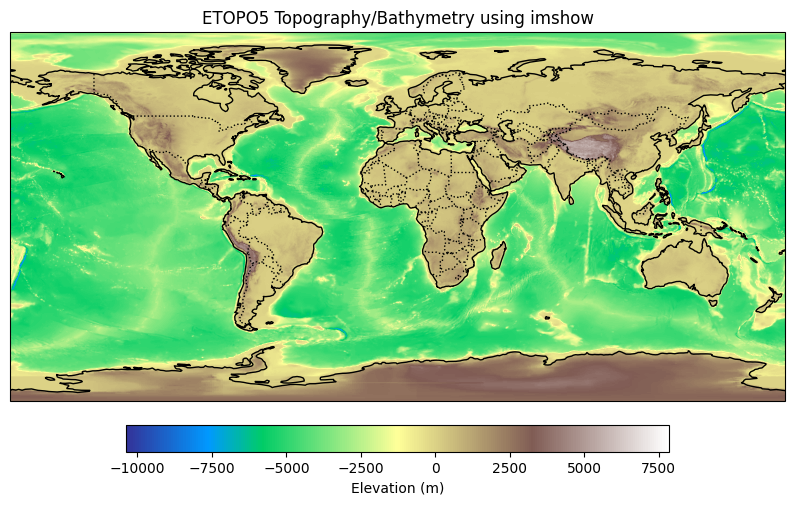

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from mpl_toolkits.basemap import shiftgrid  # still used for shifting longitude grid

# Load data
url = 'http://ferret.pmel.noaa.gov/thredds/dodsC/data/PMEL/etopo5.nc'
etopodata = Dataset(url)

topoin = etopodata.variables['ROSE'][:]
lons = etopodata.variables['ETOPO05_X'][:]
lats = etopodata.variables['ETOPO05_Y'][:]

# Shift grid so lons go from -180 to 180 instead of 0 to 360
topoin, lons = shiftgrid(180.0, topoin, lons, start=False)

# Define projection
projection = ccrs.PlateCarree()

# Setup plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=projection)

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)

# Set global extent
ax.set_global()

# Plot topography using imshow
mesh = ax.imshow(topoin, 
                 extent=[lons[0], lons[-1], lats[0], lats[-1]], 
                 cmap='terrain', 
                 transform=projection,
                 origin='lower',
                 aspect='auto')

# Add colorbar
cbar = plt.colorbar(mesh, orientation='horizontal', shrink=0.7, pad=0.05)
cbar.set_label('Elevation (m)')

plt.title("ETOPO5 Topography/Bathymetry using imshow")
plt.show()

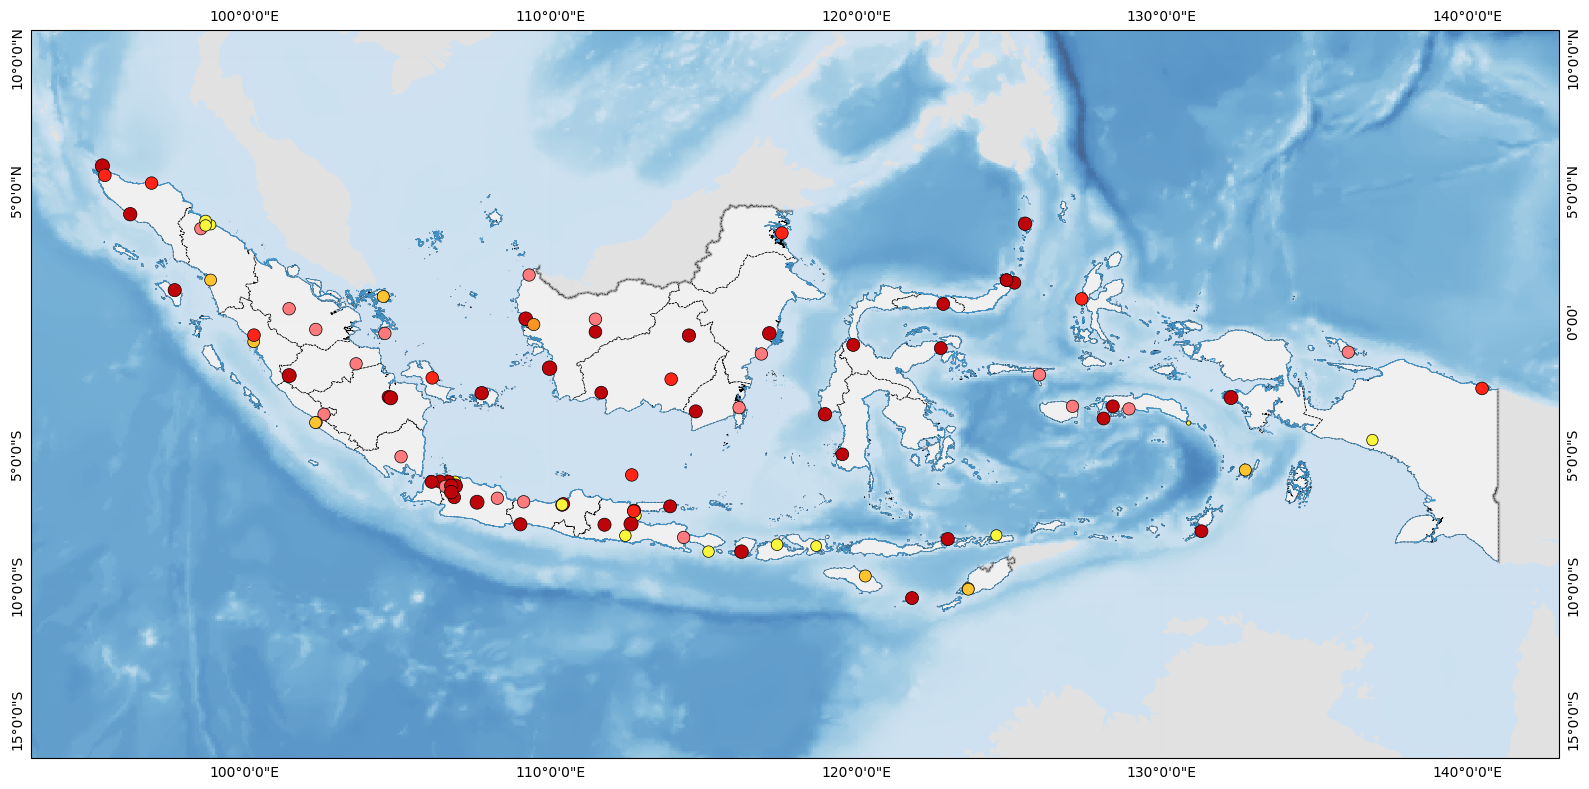

In [35]:
# Buat figure dan axis dengan proyeksi PlateCarree
fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Miller())
ax.set_extent([93, 143, -15, 10])

#SETTING GRID PETA
gl              = ax.gridlines(draw_labels=True, linewidth=0.01, color='gray', alpha=0.7, linestyle='--')
gl.xlocator     = mticker.FixedLocator(range(90, 150, 10))
gl.ylocator     = mticker.FixedLocator(range(-15, 12, 5))
gl.xformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lon(x))
gl.yformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lat(x))

#FORMATING LABELS LAT DAN LON
gl.xlabel_style = {'rotation':0,'color': 'black', 'size': 10}
gl.ylabel_style = {'rotation': 90, 'color': 'black', 'size': 10}


# Plot topography using imshow
mesh = ax.imshow(topoin, 
                 cmap='Blues_r', 
                 transform=projection,
                 origin='lower',
                 aspect='auto',
                 alpha=0.75)

#PLOTING BATAS NEGARA
# ax.add_feature(PNG, facecolor='red', edgecolor='red', linewidth=0.5, zorder=2,linestyle='solid')
# ax.add_feature(TL, facecolor='red', edgecolor='red', linewidth=0.5, zorder=2, linestyle='solid')
# ax.add_feature(ML, facecolor='red', edgecolor='red', linewidth=0.5, zorder=2, linestyle='solid')
plot_shape_boundary(PNG, linewidth=2, linestyle='solid', color='#808080', alpha=0.5)
plot_shape_boundary(TL, linewidth=2,  linestyle='solid', color='#808080', alpha=0.5)
plot_shape_boundary(ML, linewidth=2,  linestyle='solid', color='#808080', alpha=0.5)

#PLOTING LUAR NEGERI, INDONESIA, PANTAI
ax.add_feature(LN, facecolor='#e1e1e1', edgecolor='none', linewidth=0.5, zorder=1)
ax.add_feature(INDO, facecolor='#f0f0f0', edgecolor='black', linewidth=0.5, zorder=1, linestyle='--')
ax.add_feature(PANTAI, facecolor='none', edgecolor='#4292c6', linewidth=0.5, zorder=1, linestyle='solid')

#BATAS FUNGSI#################################################################################
bounds      = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
colors_list = ["#f8f53a", "#fec42f", "#ff9425","#ff7a7c", "#ff2415","#bf030b","#bf030b"]
cmap        = colors.ListedColormap(colors_list)
norm        = colors.BoundaryNorm(bounds, cmap.N)

# Konversi LAT dan LON menjadi float
pm25['LAT'] = pm25['LAT'].astype(float)
pm25['LON'] = pm25['LON'].astype(float)
pm25['TXx'] = pd.to_numeric(pm25['TXx'], errors='coerce')
# Hitung ukuran bulatan berdasarkan TXx
sizes       = (pm25['TXx'] - pm25['TXx'].min()) / (pm25['TXx'].max() - pm25['TXx'].min())
sizes       = sizes * 100 + 10  # Skala ukuran antara 20 hingga 150
#BATAS FUNGSI#################################################################################

#PLOTING POINT VALUES
sc          = ax.scatter(pm25['LON'], pm25['LAT'],c=pm25['TXx'] * 44, cmap=cmap, norm=norm, s=sizes,alpha=1, edgecolors='k', linewidths=0.5, transform=ccrs.PlateCarree(), zorder=5)
plt.tight_layout()
